In [1]:
!pip install datasets

In [2]:
from datasets import load_dataset

In [3]:
realnewslike = load_dataset("allenai/c4", "realnewslike", streaming=True, split="train")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/512 [00:00<?, ?it/s]

In [6]:
realnewslike

IterableDataset({
    features: ['text', 'timestamp', 'url'],
    num_shards: 512
})

In [7]:
for i, example in enumerate(realnewslike):
    if "Iceland" in example["text"]:
        print(example)
    if i == 10000:
        break

{'text': 'Kerth, 67, was selected from 164 applicants to be the organization’s new chief executive. He sits on the board of the Sacramento Municipal Utility District and is a scion of the Kerth family who founded the American Ice Co. and the Iceland skating rink in North Sacramento. He is responsible for the design of ice rinks in what’s now called Sleep Train Arena in Sacramento and an outdoor rink at Squaw Valley’s High Camp in 1990.\nVeteran nonprofit leader Pam Saltenberger, who served as Sacramento Habitat’s interim CEO for about six months, said she and other members of the executive search team felt that Kerth’s experience in the political arena would help the organization lead and navigate discussions about how governments and nonprofits can work together to ensure there’s adequate housing for low-income residents.\nThe loss of government funding is not the only challenge for the Sacramento Habitat, which has a budget of $5.9 million for the fiscal year ending in June. Nationwi

C4의 realnewslike 하위 집합을 사용해 단어 빈도를 분석합니다.
- 단어: 공백으로 구분된 연속된 문자열
- 불용어(stop words) 제외
- 주제별 과소/과대 표현 확인

In [10]:
STOP_WORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'is', 'are', 'was', 'were', 'be', 'been',
    'being', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'could', 'should', 'may', 'might', 'shall', 'can', 'that', 'this',
    'these', 'those', 'it', 'its', 'as', 'not', 'no', 'so', 'if', 'he',
    'she', 'they', 'we', 'you', 'i', 'his', 'her', 'their', 'our', 'your',
    'my', 'who', 'which', 'what', 'when', 'where', 'how', 'all', 'more',
    'about', 'up', 'out', 'than', 'also', 'into', 'after', 'before',
    'over', 'between', 'through', 'during', 'each', 'both', 'few', 'just',
    'said', 'then', 'there', 'here', 'only', 'new', 'other', 'some',
    'any', 'them', 'him', 'me', 'us', 's', 'one', 'two', 'three',
    'while', 'because', 'since', 'until', 'though', 'although', 'however',
    'even', 'very', 'much', 'many', 'most', 'same', 'such', 'like', 'well'
}

print(f"불용어 수: {len(STOP_WORDS)}")

불용어 수: 116


In [ ]:
from collections import Counter

word_counter = Counter()

N = 10_000

for i, example in enumerate(realnewslike):
    if i >= N:
        break

    text = example["text"].lower()
    words = text.split()

    filtered = [w.strip('.,!?;:"\'-()[]{}') for w in words]
    filtered = [w for w in filtered if w and w.isalpha() and w not in STOP_WORDS]
    word_counter.update(filtered)

print(f"처리된 샘플 수: {i + 1:,}")
print(f"고유 단어 수: {len(word_counter):,}")
print(f"총 단어 토큰 수: {sum(word_counter.values()):,}")

처리된 샘플 수: 10,002
고유 단어 수: 89,680
총 단어 토큰 수: 2,220,384


In [15]:
!pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 12.3 MB/s  0:00:00 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 11.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


=== Most common Top 30 ===
   1. people              : 6,511
   2. time                : 6,293
   3. first               : 6,095
   4. year                : 5,987
   5. last                : 5,332
   6. years               : 5,195
   7. now                 : 4,975
   8. get                 : 4,341
   9. state               : 3,852
  10. make                : 3,847
  11. back                : 3,449
  12. work                : 3,364
  13. way                 : 3,307
  14. against             : 3,182
  15. million             : 3,098
  16. take                : 3,088
  17. city                : 3,046
  18. world               : 3,022
  19. made                : 3,021
  20. day                 : 3,013
  21. company             : 2,978
  22. see                 : 2,975
  23. home                : 2,957
  24. still               : 2,956
  25. percent             : 2,885
  26. says                : 2,882
  27. president           : 2,872
  28. government          : 2,858
  29. down           

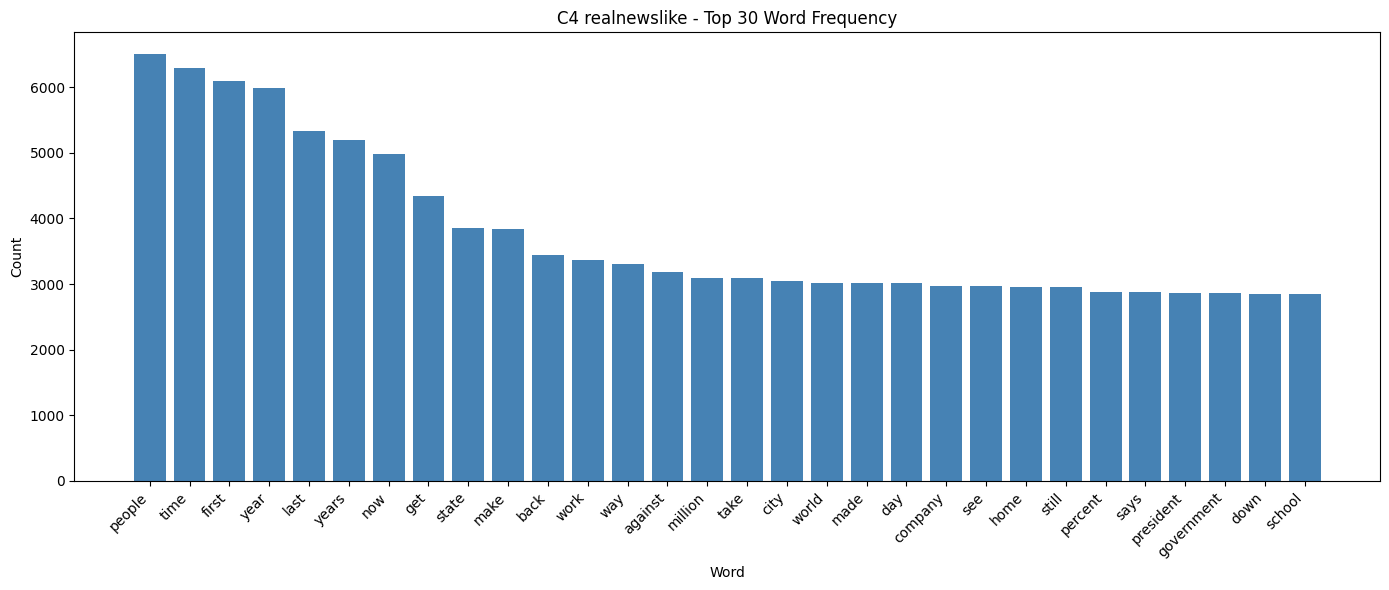

In [17]:
import matplotlib.pyplot as plt

top_n = 30
top_words = word_counter.most_common(top_n)
words, counts = zip(*top_words)

print(f"=== Most common Top {top_n} ===")
for rank, (word, count) in enumerate(top_words, 1):
    print(f"  {rank:2d}. {word:20s}: {count:,}")

plt.figure(figsize=(14, 6))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title(f'C4 realnewslike - Top {top_n} Word Frequency')
plt.xlabel('Word')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

=== Total word frequency by topic ===
  Business/Economy: 19,523 (20.4%)  █████████████████████████████████████████████████████████████████
  Politics/Government: 14,497 (15.1%)  ████████████████████████████████████████████████
  Sports         : 13,709 (14.3%)  █████████████████████████████████████████████
  Entertainment  : 11,274 (11.8%)  █████████████████████████████████████
  Technology     : 10,726 (11.2%)  ███████████████████████████████████
  Education      : 10,507 (11.0%)  ███████████████████████████████████
  Health/Medicine:  8,407 (8.8%)  ████████████████████████████
  Science/Environment:  7,124 (7.4%)  ███████████████████████


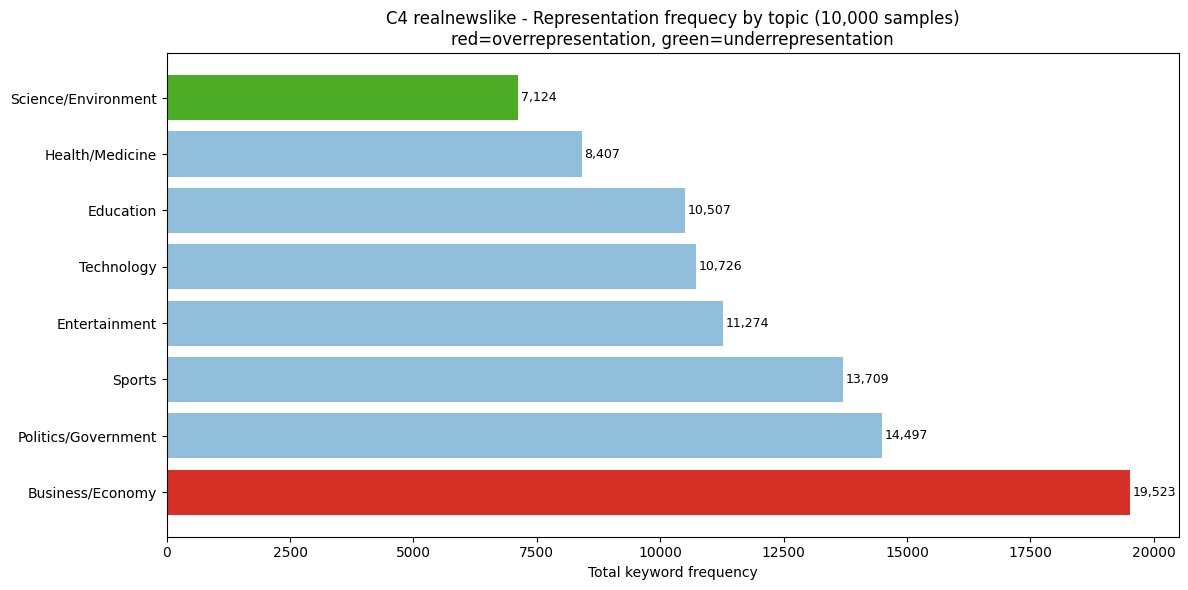


[overrepresentation] Business/Economy: 19,523회
[underrepresentation] Science/Environment: 7,124회

분석: 'Business/Economy' 주제가 realnewslike 특성상 뉴스 콘텐츠에서 가장 많이 등장하며,
      'Science/Environment' 관련 키워드는 상대적으로 적게 등장합니다.


In [20]:
# 주제별 과소/과대 표현 분석
topic_keywords = {
    'Politics/Government': ['president', 'government', 'political', 'congress', 'senate',
                            'election', 'democrat', 'republican', 'trump', 'vote', 'policy', 'law'],
    'Sports': ['game', 'team', 'season', 'player', 'coach', 'win', 'league',
               'championship', 'score', 'match', 'football', 'basketball', 'baseball'],
    'Business/Economy': ['company', 'business', 'market', 'stock', 'price', 'economic',
                         'billion', 'million', 'growth', 'industry', 'bank', 'share'],
    'Technology': ['technology', 'data', 'software', 'digital', 'internet', 'online',
                   'app', 'platform', 'tech', 'computer', 'service', 'google'],
    'Health/Medicine': ['health', 'medical', 'hospital', 'doctor', 'patient', 'drug',
                        'cancer', 'disease', 'treatment', 'research', 'study', 'clinical'],
    'Entertainment': ['film', 'movie', 'music', 'show', 'star', 'actor', 'award',
                      'director', 'album', 'television', 'series', 'play'],
    'Science/Environment': ['climate', 'science', 'environment', 'energy', 'space', 'ocean',
                            'planet', 'carbon', 'species', 'nature', 'water', 'air'],
    'Education': ['school', 'student', 'education', 'university', 'teacher',
                  'college', 'learning', 'academic', 'children', 'class'],
}

topic_counts = {
    topic: sum(word_counter.get(kw, 0) for kw in keywords)
    for topic, keywords in topic_keywords.items()
}

sorted_topics = sorted(topic_counts.items(), key=lambda x: x[1], reverse=True)
total = sum(topic_counts.values())

print("=== Total word frequency by topic ===")
for topic, count in sorted_topics:
    pct = count / total * 100
    bar = '█' * (count // 300)
    print(f"  {topic:15s}: {count:6,} ({pct:.1f}%)  {bar}")

# 수평 막대 그래프
topics, counts = zip(*sorted_topics)
max_count, min_count = max(counts), min(counts)
colors = ['#d73027' if c == max_count else '#4dac26' if c == min_count else '#91bfdb' for c in counts]

plt.figure(figsize=(12, 6))
bars = plt.barh(topics, counts, color=colors)
plt.xlabel('Total keyword frequency')
plt.title(f'C4 realnewslike - Representation frequecy by topic ({N:,} samples)\nred=overrepresentation, green=underrepresentation')
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
             f'{count:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"\n[overrepresentation] {sorted_topics[0][0]}: {sorted_topics[0][1]:,}회")
print(f"[underrepresentation] {sorted_topics[-1][0]}: {sorted_topics[-1][1]:,}회")
print(f"\n분석: '{sorted_topics[0][0]}' 주제가 realnewslike 특성상 뉴스 콘텐츠에서 가장 많이 등장하며,")
print(f"      '{sorted_topics[-1][0]}' 관련 키워드는 상대적으로 적게 등장합니다.")